# **LOAD & CHECK DATA**

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import re
from PIL import Image
import requests
import random
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
books=pd.read_csv("data/Books.csv")
books.head(3)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...


In [3]:
ratings=pd.read_csv("data/Ratings.csv")
ratings.head(3)

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0


In [4]:
users=pd.read_csv("data/Users.csv")
users.head(3)

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN


In [5]:
print("Books Shape: " ,books.shape )
print("Ratings Shape: " ,ratings.shape )
print("Users Shape: " ,users.shape )

Books Shape:  (271360, 8)
Ratings Shape:  (1149780, 3)
Users Shape:  (278858, 3)


# **PREPROCESSING**

In [6]:
books_data=books.merge(ratings,on="ISBN")
books_data.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,User-ID,Book-Rating
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,2,0
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,8,5
2,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,11400,0
3,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,11676,8
4,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,41385,0


In [7]:
df=books_data.copy()
df.dropna(inplace=True)
df.reset_index(drop=True,inplace=True)
df.drop(columns=["ISBN","Year-Of-Publication","Image-URL-S","Image-URL-M"],inplace=True)
df.drop(index=df[df["Book-Rating"]==0].index,inplace=True)
df["Book-Title"]=df["Book-Title"].apply(lambda x: re.sub("[\W_]+"," ",x).strip())
df.head()

,Book-Title,Book-Author,Publisher,Image-URL-L,User-ID,Book-Rating
1,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,8,5
3,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,11676,8
5,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,67544,8
8,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,116866,9
9,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,123629,9


# **POPULARITY BASED RECOMMENDATION SYSTEM**

* Popularity based recommendation systems are based on the rating of items by all the users.
* Popularity based recommendation systems works with the trend. It basically uses the items which are in trend right now.

In [8]:
def popular_books(df,n=100):
    rating_count=df.groupby("Book-Title").count()["Book-Rating"].reset_index()
    rating_count.rename(columns={"Book-Rating":"NumberOfVotes"},inplace=True)
    
    rating_average=df.groupby("Book-Title")["Book-Rating"].mean().reset_index()
    rating_average.rename(columns={"Book-Rating":"AverageRatings"},inplace=True)
    
    popularBooks=rating_count.merge(rating_average,on="Book-Title")
    
    def weighted_rate(x):
        v=x["NumberOfVotes"]
        R=x["AverageRatings"]
        
        return ((v*R) + (m*C)) / (v+m)
    
    C=popularBooks["AverageRatings"].mean()
    m=popularBooks["NumberOfVotes"].quantile(0.90)
    
    popularBooks=popularBooks[popularBooks["NumberOfVotes"] >=250]
    popularBooks["Popularity"]=popularBooks.apply(weighted_rate,axis=1)
    popularBooks=popularBooks.sort_values(by="Popularity",ascending=False)
    return popularBooks[["Book-Title","NumberOfVotes","AverageRatings","Popularity"]].reset_index(drop=True).head(n)

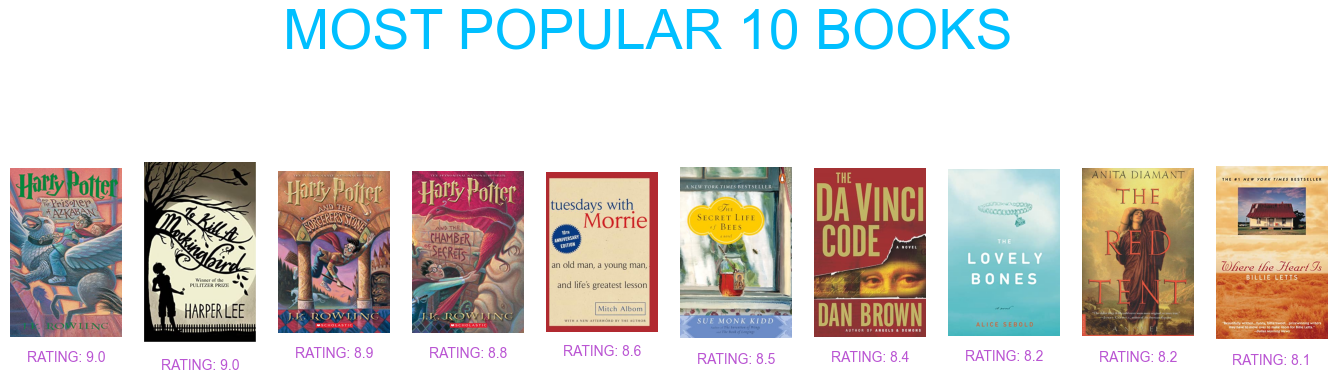

In [9]:
from io import BytesIO
top_ten=pd.DataFrame(popular_books(df,10))
fig, ax = plt.subplots(1, 10, figsize=(17,5))
fig.suptitle("MOST POPULAR 10 BOOKS", fontsize=40, color="deepskyblue")
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'
}

for i in range(len(top_ten["Book-Title"].tolist())):
    title = top_ten["Book-Title"].tolist()[i]
    url = df.loc[df["Book-Title"] == title, "Image-URL-L"][:1].values[0]

    try:
        response = requests.get(url, headers=headers, timeout=5)
        response.raise_for_status()

        img = Image.open(BytesIO(response.content))
        ax[i].imshow(img)

    except Exception as e:
        ax[i].text(0.5, 0.5, 'Brak\nokładki', ha='center', va='center')
    ax[i].axis("off")
    mean_rating = round(df[df["Book-Title"] == title]["Book-Rating"].mean(), 1)
    ax[i].set_title(f"RATING: {mean_rating}", y=-0.20, color="mediumorchid", fontsize=10)
plt.show()

# **ITEM-BASED COLLABORATIVE FILTERING**

In [10]:
def item_based(bookTitle):
    bookTitle = str(bookTitle)

    if bookTitle in df["Book-Title"].values:
        counts = df["Book-Title"].value_counts()
        rare_books = counts[counts <= 200].index
        common_books = df[~df["Book-Title"].isin(rare_books)]

        if bookTitle in rare_books:
            most_common = pd.Series(common_books["Book-Title"].unique()).sample(3).values
            print("No Recommendations for this Book ☹️ \n ")
            print("YOU MAY TRY: \n ")
            print("{}".format(most_common[0]), "\n")
            print("{}".format(most_common[1]), "\n")
            print("{}".format(most_common[2]), "\n")
        else:
            common_books_pivot = common_books.pivot_table(index=["User-ID"], columns=["Book-Title"], values="Book-Rating")
            title = common_books_pivot[bookTitle]
            recommendation_df = pd.DataFrame(common_books_pivot.corrwith(title).sort_values(ascending=False)).reset_index(drop=False)

            if bookTitle in [t for t in recommendation_df["Book-Title"]]:
                recommendation_df = recommendation_df.drop(recommendation_df[recommendation_df["Book-Title"] == bookTitle].index[0])

            less_rating = []
            for i in recommendation_df["Book-Title"]:
                if df[df["Book-Title"] == i]["Book-Rating"].mean() < 5:
                    less_rating.append(i)

            if recommendation_df.shape[0] - len(less_rating) > 5:
                recommendation_df = recommendation_df[~recommendation_df["Book-Title"].isin(less_rating)]

            recommendation_df = recommendation_df[0:5]
            recommendation_df.columns = ["Book-Title", "Correlation"]

            fig, ax = plt.subplots(1, 5, figsize=(17,5))
            fig.suptitle("WOULD YOU LIKE to TRY THESE BOOKS?", fontsize=40, color="deepskyblue")


            headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/114.0.0.0 Safari/537.36'}

            for i in range(len(recommendation_df["Book-Title"].tolist())):
                rec_title = recommendation_df["Book-Title"].tolist()[i]
                url = df.loc[df["Book-Title"] == rec_title, "Image-URL-L"][:1].values[0]


                try:
                    response = requests.get(url, headers=headers, stream=True, timeout=5)
                    response.raise_for_status()
                    img = Image.open(BytesIO(response.content))
                    ax[i].imshow(img)
                except Exception as e:
                    ax[i].text(0.5, 0.5, 'Brak\nokładki', ha='center', va='center')

                ax[i].axis("off")
                mean_rating = round(df[df["Book-Title"] == rec_title]["Book-Rating"].mean(), 1)
                ax[i].set_title("RATING: {} ".format(mean_rating), y=-0.20, color="mediumorchid", fontsize=22)


            plt.show()
    else:
        print("❌ COULD NOT FIND ❌")

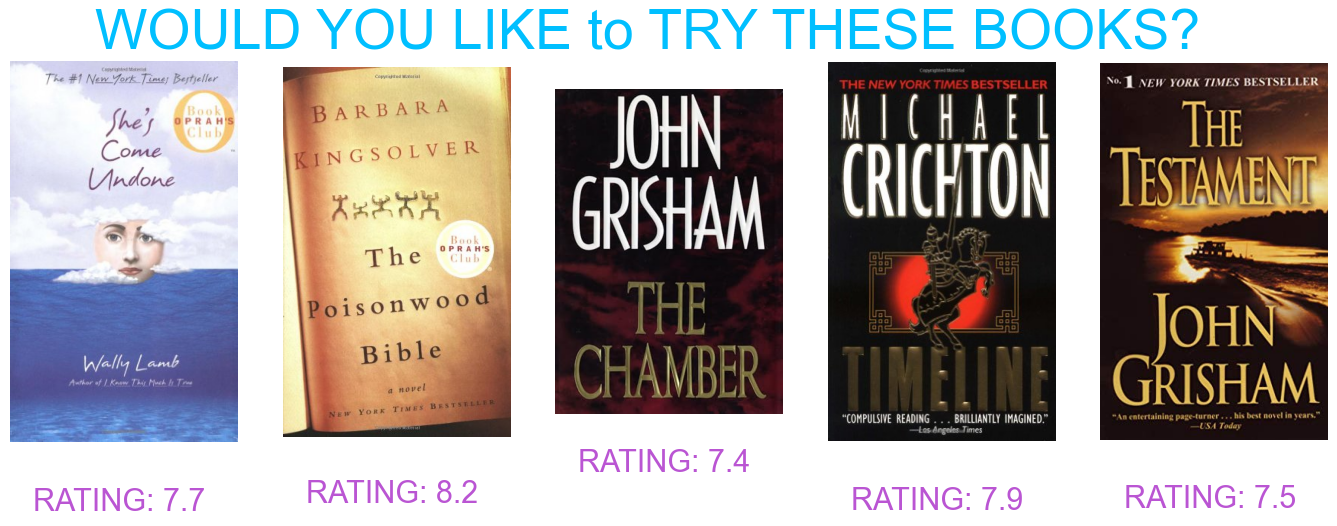

In [11]:
item_based("Me Talk Pretty One Day")

In [12]:
item_based("From One to One Hundred")

No Recommendations for this Book ☹️ 
 
YOU MAY TRY: 
 
House of Sand and Fog 

The Red Tent Bestselling Backlist 

Harry Potter and the Sorcerer s Stone Harry Potter Paperback 



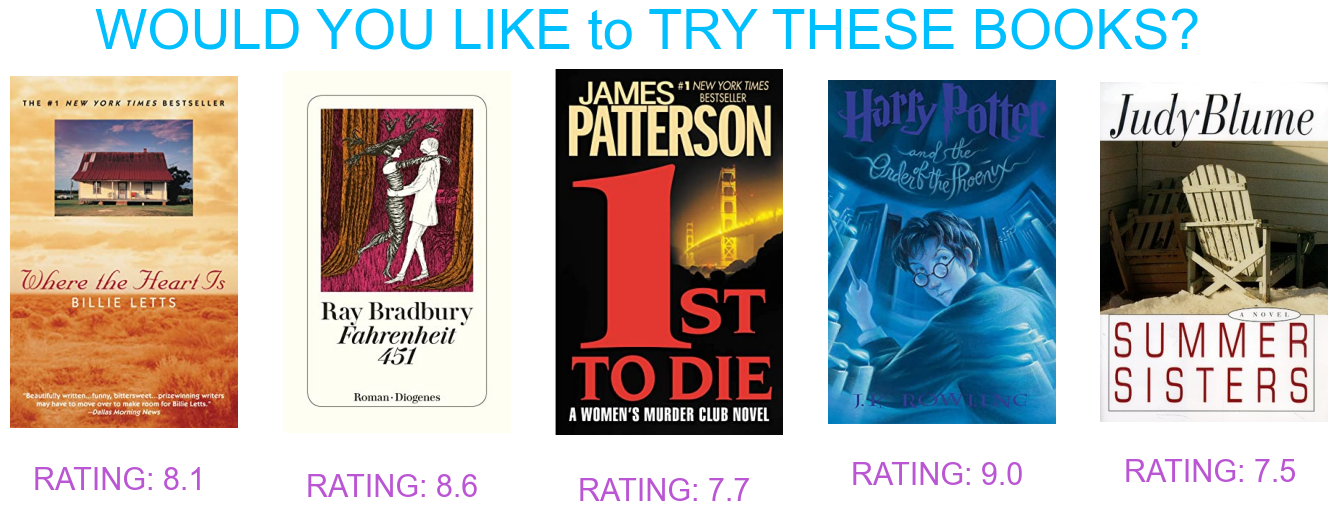

In [13]:
item_based("The Da Vinci Code")

In [14]:
item_based("Barbie")

❌ COULD NOT FIND ❌


# **USER-BASED COLLABORATIVE FILTERING**

In [15]:
new_df=df[df['User-ID'].map(df['User-ID'].value_counts()) > 200]  # Drop users who vote less than 200 times.
users_pivot=new_df.pivot_table(index=["User-ID"],columns=["Book-Title"],values="Book-Rating")
users_pivot.fillna(0,inplace=True)

Book-Title,01 01 00 A Novel of the Millennium,01 01 00 The Novel of the Millennium,1 000 Makers of the Millennium The Men and Women Who Have Shaped the Last 1 000 Years,1 001 Old Time Garden Tips Timeless Bits of Wisdom on How to Grow Everything Organically from the Good Old Days When Everyone Did,1 003 Great Things About Kids,1 2 3 Music,1 401 More Things That P Ss Me Off,10 000 Answers The Ultimate Trivia Encyclopedia,10 000 Things to Praise God for,10 000 dreams interpreted A dictionary of dreams,...,street bible the,termcap amp terminfo O Reilly Nutshell,the Dark Light Years,them Modern Library,together by christmas,wet sand raven tracks,whataboutrick com a poetic tribute to Richard A Ricci,Â Corre perro corre,Â Eres tu mi mamÃ Are You My Mother,Ã Â ber das Fernsehen
User-ID,,,,,,,,,,,,,,,,,,,,,
4385,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6251,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6575,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11676,8.0,6.0,0.0,7.0,8.0,8.0,4.0,0.0,0.0,0.0,...,9.0,0.0,0.0,0.0,0.0,8.0,5.0,10.0,0.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
265889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
269566,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
def users_choice(id):
    
    users_fav=new_df[new_df["User-ID"]==id].sort_values(["Book-Rating"],ascending=False)[0:5]
    return users_fav

In [17]:
def user_based(new_df,id):
    if id not in new_df["User-ID"].values:
        print("❌ User NOT FOUND ❌")
        
        
    else:
        index=np.where(users_pivot.index==id)[0][0]
        similarity=cosine_similarity(users_pivot)
        similar_users=list(enumerate(similarity[index]))
        similar_users = sorted(similar_users,key = lambda x:x[1],reverse=True)[0:5]
    
        user_rec=[]
    
        for i in similar_users:
                data=df[df["User-ID"]==users_pivot.index[i[0]]]
                user_rec.extend(list(data.drop_duplicates("User-ID")["User-ID"].values))
        
    return user_rec

In [18]:
def common(new_df,user,user_id):
    x=new_df[new_df["User-ID"]==user_id]
    recommend_books=[]
    user=list(user)
    for i in user:
        y=new_df[(new_df["User-ID"]==i)]
        books=y.loc[~y["Book-Title"].isin(x["Book-Title"]),:]
        books=books.sort_values(["Book-Rating"],ascending=False)[0:5]
        recommend_books.extend(books["Book-Title"].values)
        
    return recommend_books[0:5]

🟦 USER: 225087 


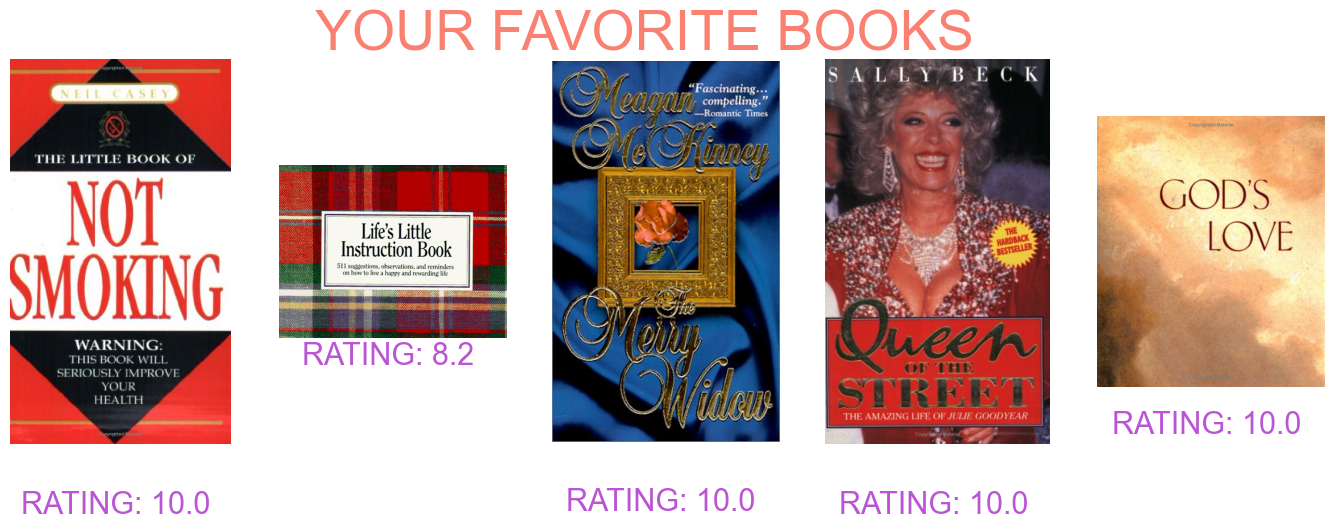

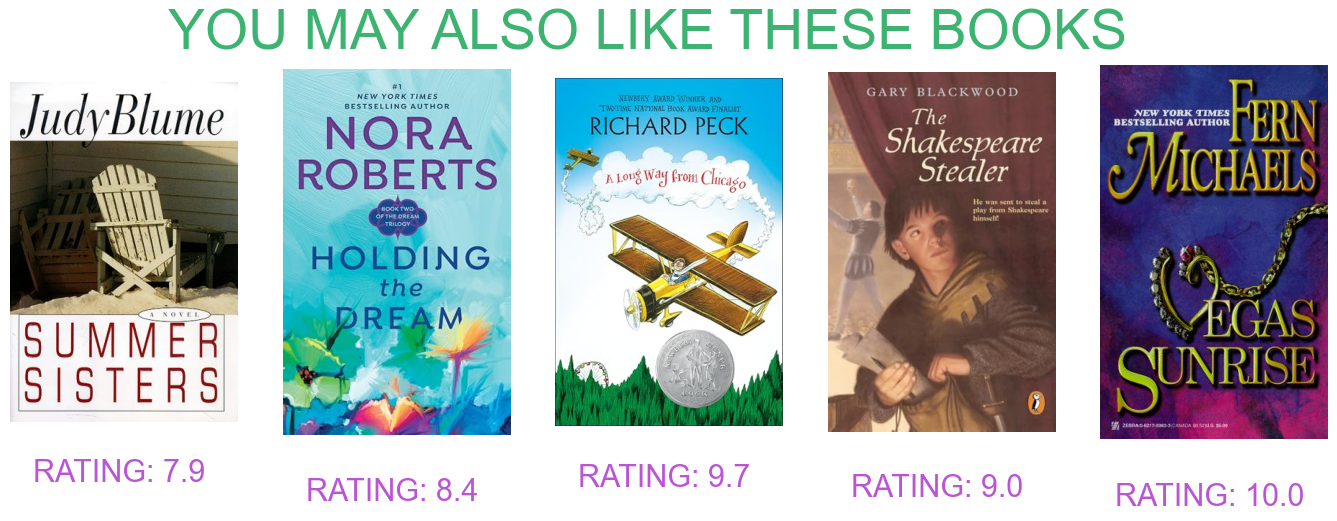

In [19]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/114.0.0.0 Safari/537.36'
}

user_id = random.choice(new_df["User-ID"].values)
user_choice_df = pd.DataFrame(users_choice(user_id))
user_favorite = users_choice(user_id)
n = len(user_choice_df["Book-Title"].values)

print("🟦 USER: {} ".format(user_id))

fig, ax = plt.subplots(1, n, figsize=(17,5))
fig.suptitle("YOUR FAVORITE BOOKS", fontsize=40, color="salmon")

for i in range(n):
    title = user_choice_df["Book-Title"].tolist()[i]
    url = new_df.loc[new_df["Book-Title"] == title, "Image-URL-L"][:1].values[0]

    try:
        response = requests.get(url, headers=headers, stream=True, timeout=5)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
        ax[i].imshow(img)
    except Exception as e:
        ax[i].text(0.5, 0.5, 'Brak\nokładki', ha='center', va='center')

    ax[i].axis("off")
    mean_rating = round(new_df[new_df["Book-Title"] == title]["Book-Rating"].mean(), 1)
    ax[i].set_title("RATING: {} ".format(mean_rating), y=-0.20, color="mediumorchid", fontsize=22)

plt.show()

user_based_rec = user_based(new_df, user_id)
books_for_user = common(new_df, user_based_rec, user_id)
books_for_userDF = pd.DataFrame(books_for_user, columns=["Book-Title"])

fig, ax = plt.subplots(1, 5, figsize=(17,5))
fig.suptitle("YOU MAY ALSO LIKE THESE BOOKS", fontsize=40, color="mediumseagreen")

for i in range(5):
    if i >= len(books_for_userDF):
        ax[i].axis("off")
        continue

    title = books_for_userDF["Book-Title"].tolist()[i]
    url = new_df.loc[new_df["Book-Title"] == title, "Image-URL-L"][:1].values[0]

    try:
        response = requests.get(url, headers=headers, stream=True, timeout=5)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
        ax[i].imshow(img)
    except Exception as e:
        ax[i].text(0.5, 0.5, 'Brak\nokładki', ha='center', va='center')

    ax[i].axis("off")
    mean_rating = round(new_df[new_df["Book-Title"] == title]["Book-Rating"].mean(), 1)
    ax[i].set_title("RATING: {} ".format(mean_rating), y=-0.20, color="mediumorchid", fontsize=22)

plt.show()

# **CONTENT-BASED COLLABORATIVE FILTERING** 

In [20]:
def content_based(bookTitle):
    bookTitle = str(bookTitle)

    if bookTitle in df["Book-Title"].values:
        counts = df["Book-Title"].value_counts()
        rare_books = counts[counts <= 200].index
        common_books = df[~df["Book-Title"].isin(rare_books)]

        if bookTitle in rare_books:
            most_common = pd.Series(common_books["Book-Title"].unique()).sample(3).values
            print("No Recommendations for this Book ☹️ \n ")
            print("YOU MAY TRY: \n ")
            print("{}".format(most_common[0]), "\n")
            print("{}".format(most_common[1]), "\n")
            print("{}".format(most_common[2]), "\n")
        else:
            common_books = common_books.drop_duplicates(subset=["Book-Title"])
            common_books.reset_index(drop=True, inplace=True)
            common_books["index"] = [i for i in range(common_books.shape[0])]

            targets = ["Book-Title", "Book-Author", "Publisher"]
            common_books["all_features"] = [" ".join(common_books[targets].iloc[i,].values) for i in range(common_books[targets].shape[0])]

            vectorizer = CountVectorizer()
            common_booksVector = vectorizer.fit_transform(common_books["all_features"])
            similarity = cosine_similarity(common_booksVector)

            index = common_books[common_books["Book-Title"] == bookTitle]["index"].values[0]
            similar_books = list(enumerate(similarity[index]))
            similar_booksSorted = sorted(similar_books, key=lambda x:x[1], reverse=True)[1:6]

            books = []
            for i in range(len(similar_booksSorted)):
                books.append(common_books[common_books["index"] == similar_booksSorted[i][0]]["Book-Title"].item())

            fig, ax = plt.subplots(1, 5, figsize=(17,5))
            fig.suptitle("YOU MAY ALSO LIKE THESE BOOKS", fontsize=40, color="chocolate")

            headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/114.0.0.0 Safari/537.36'}

            for i in range(len(books)):
                url = common_books.loc[common_books["Book-Title"] == books[i], "Image-URL-L"][:1].values[0]
                try:
                    response = requests.get(url, headers=headers, stream=True, timeout=5)
                    response.raise_for_status()
                    img = Image.open(BytesIO(response.content))
                    ax[i].imshow(img)
                except Exception as e:
                    ax[i].text(0.5, 0.5, 'Brak\nokładki', ha='center', va='center')

                ax[i].axis("off")
                mean_rating = round(df[df["Book-Title"] == books[i]]["Book-Rating"].mean(), 1)
                ax[i].set_title("RATING: {}".format(mean_rating), y=-0.20, color="mediumorchid", fontsize=22)
            plt.show()

    else:
        print("❌ COULD NOT FIND ❌")

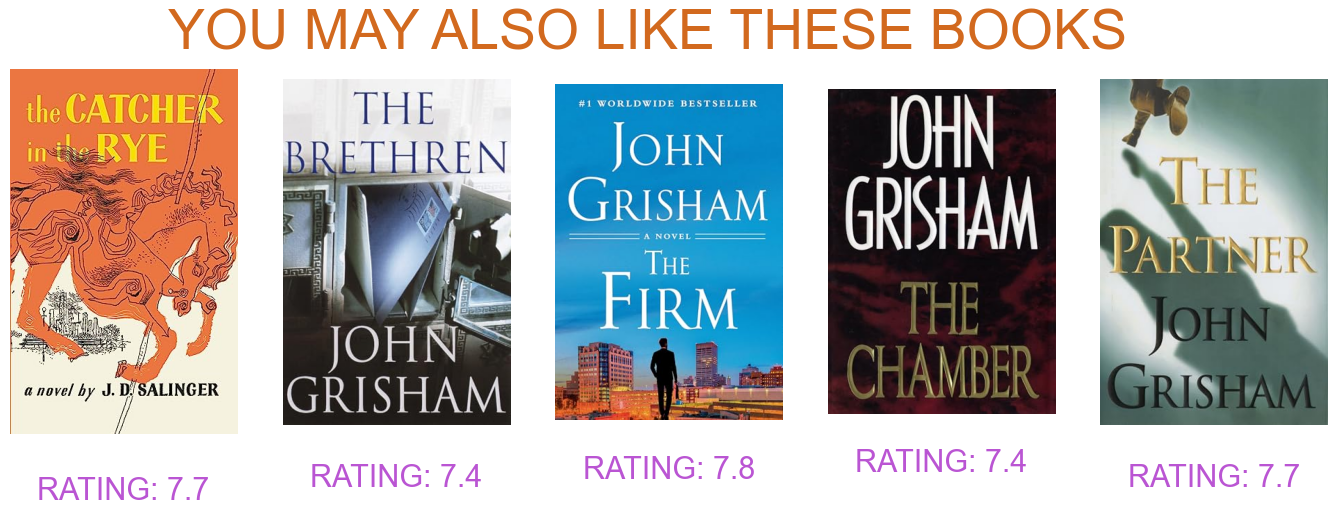

In [21]:
content_based("The Da Vinci Code")

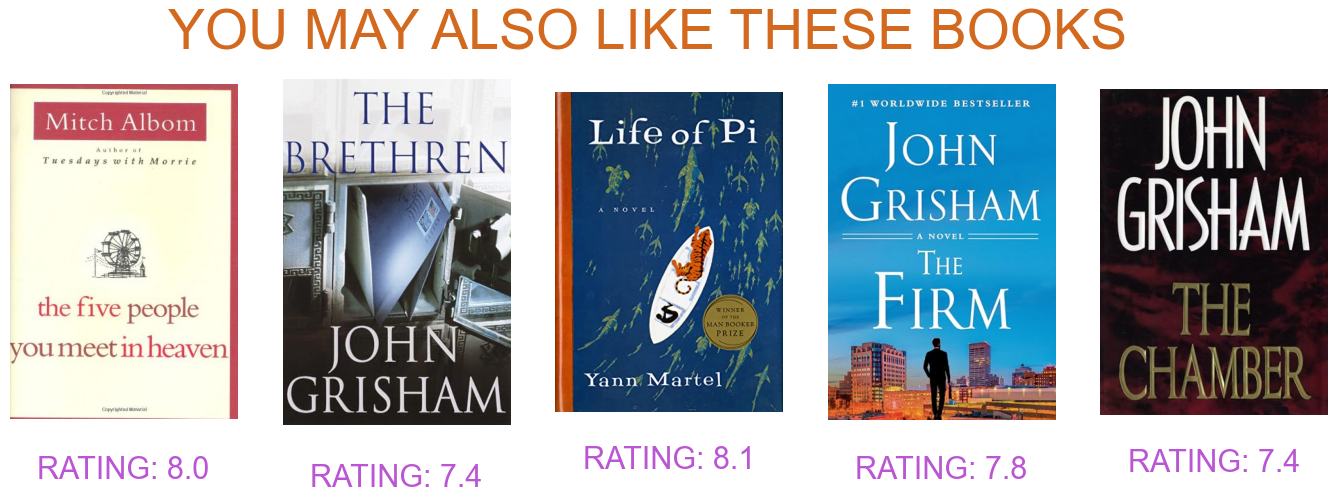

In [22]:
content_based("Tuesdays with Morrie An Old Man a Young Man and Life s Greatest Lesson")

In [23]:
content_based("A Soldier of the Great War")

No Recommendations for this Book ☹️ 
 
YOU MAY TRY: 
 
Harry Potter and the Order of the Phoenix Book 5 

The Lovely Bones A Novel 

The Red Tent Bestselling Backlist 



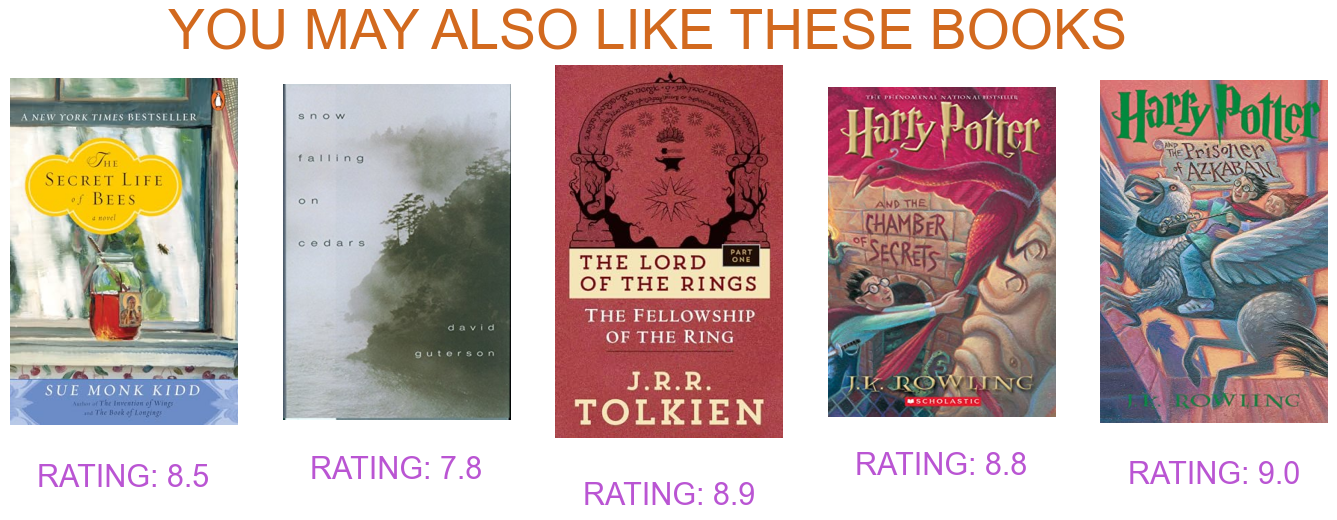

In [24]:
content_based("Life of Pi")